<h1><b>MAIN.PY</b></h1>

<h2><b>TRAINING</b></h2>

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

DATASET_PATH = "/workspace/Dataset/nyudepthv2"

try:
    import kagglehub
    dataset_path = kagglehub.dataset_download("awsaf49/nyuv2-official-split-dataset")
    print("Kagglehub detected. Using downloaded path:", dataset_path)
except ImportError:
    dataset_path = DATASET_PATH
    print("Kagglehub not found (Vitis AI Docker environment). Falling back to manual path:", dataset_path)
assert os.path.exists(dataset_path), f"CRITICAL: The dataset path '{dataset_path}' does not exist!"





/home/mado/.conda/envs/depth_estimation_kv260/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Kagglehub detected. Using downloaded path: /home/mado/.cache/kagglehub/datasets/awsaf49/nyuv2-official-split-dataset/versions/1


In [23]:
from src.train import train

model_path = "./models/model5.pth"


In [5]:
train(
    dataset_path=dataset_path,
    epochs=10,
    num_imgs=50000,
    model_path=model_path
)

NameError: name 'train' is not defined

<h2><b>EVALUATION</b></h2>

In [4]:
from src.utils import get_dataframe

print("TEST DATASET")
test_dataframe = get_dataframe(dataset_path, "test")
test_dataframe.head()

TEST DATASET
Fichiers trouvés : 0 paires rgb/depth


,rgb,depth


In [48]:
import torchvision.transforms as transforms

from src.dataset import Nyudepth_png

transform = transforms.Compose([transforms.Resize([224,224])])
test_dataset = Nyudepth_png(
    dataset_path=os.path.join(dataset_path, "test"),
    dataframe=test_dataframe.reset_index(drop="true"),
    transform_shape=transform, 
    transform_color=None
)
len(test_dataset)

654

In [49]:
import matplotlib.pyplot as plt
import numpy as np
from random import randint

im, de = test_dataset[randint(0, len(test_dataset)-1)]

cmap = plt.get_cmap("magma").copy()
cmap.set_bad(color="black")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

# 1. Image originale
ax[0].imshow((im.squeeze().permute(1,2,0) + 1.0)/2.0)
ax[0].set_title("Image originale")

# 2. Carte de distance (déjà normalisée entre 0 et 1 dans votre dataset)
# Attention : j'ai retiré le "+1 / 2" qui était là avant, car vos données sont déjà en [0, 1]
pos = ax[1].imshow(de.squeeze(), cmap=cmap)
ax[1].set_title("Carte de distance")

# 3. Configuration de la Colorbar
cbar = fig.colorbar(pos, ax=ax[1], orientation='vertical', fraction=0.046, pad=0.04)
cbar.set_label('Distance (mètres)', rotation=270, labelpad=15)

# --- INVERSION DE LA NORMALISATION POUR LES MÈTRES ---
# On crée des repères réguliers entre 0 et 1 sur la colorbar
ticks = np.linspace(0, 1, 6) # 6 repères de 0 à 1
cbar.set_ticks(ticks)

# Formule inverse de : (dep_data - 0.7) / (10.0 - 0.7)
# Devient : valeur_norm * (10.0 - 0.7) + 0.7
distances_en_metres = ticks * (10.0 - 0.7) + 0.7

# On applique les vraies valeurs en mètres comme texte sur la légende
cbar.set_ticklabels([f"{dist:.2f}m" for dist in distances_en_metres])
# -----------------------------------------------------

plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: './dataset/nyudepthv2/test/./dataset/nyudepthv2/test/official/rgb_00556.png'

In [50]:
from torch.utils.data import DataLoader

test_dataloader = DataLoader(test_dataset, batch_size=32, shuffle=True, num_workers=8)


In [51]:
import torch
from src.model import UNet


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model = UNet().to(device)
checkpoint = torch.load(model_path)
model.load_state_dict(checkpoint, strict=False)
model.eval()

print(device)
print(model_path)

NameError: name 'model_path' is not defined

In [52]:
from torchview import draw_graph

model_graph = draw_graph(model, input_size=(2, 3, 224, 224), expand_nested=True)
model_graph.visual_graph.render(filename='outputs/unet', format='png')

ModuleNotFoundError: No module named 'torchview'

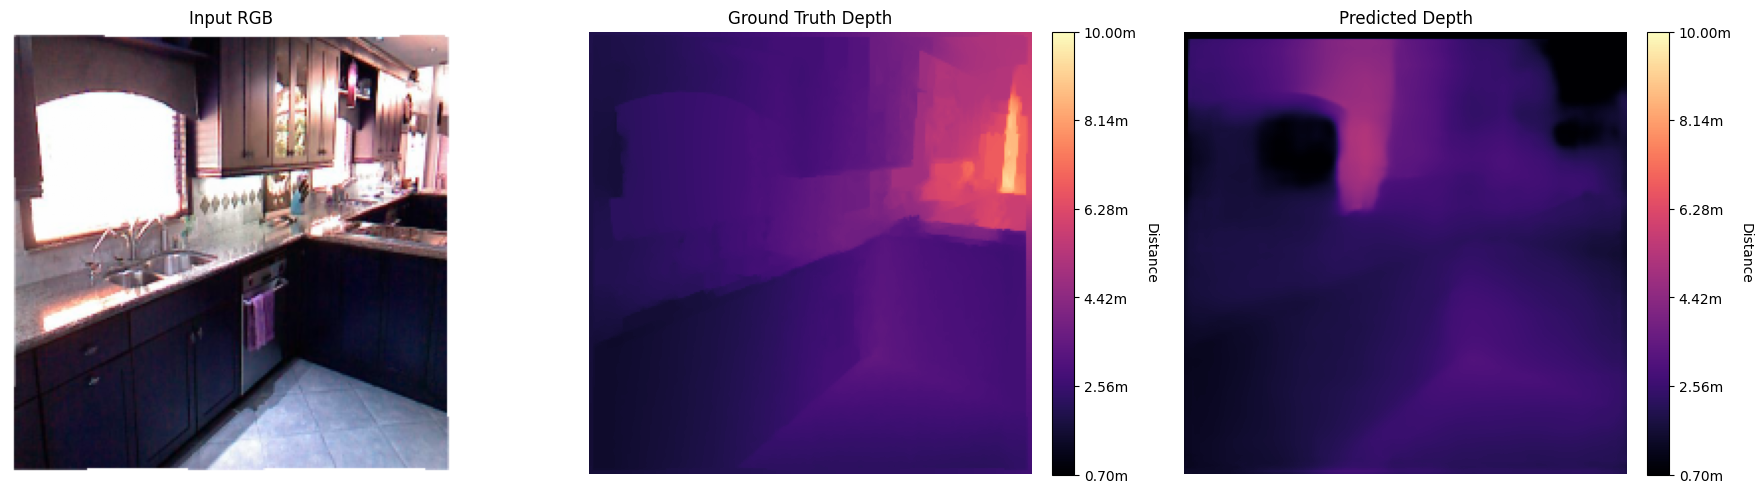

In [88]:
from src.utils import predict
from random import randint
import matplotlib.pyplot as plt
import numpy as np

# Pick a random sample
im, dm = test_dataset[randint(0, len(test_dataset)-1)]
dm_np = dm.squeeze().cpu().numpy()

# Run prediction
de_p = predict(im, model, device)

# --- SÉCURITÉ : AJUSTEMENT DE LA PRÉDICTION ---
# Si ta prédiction max est supérieure à 1.0, c'est qu'elle est déjà en mètres.
# On la normalise entre 0 et 1 pour l'affichage pour qu'elle corresponde au GT.
if de_p.max() > 1.0:
    de_p_display = (de_p - 0.7) / (10.0 - 0.7)
    de_p_display = np.clip(de_p_display, 0.0, 1.0)
else:
    de_p_display = de_p
# ----------------------------------------------

# Setup color map
cmap = plt.get_cmap("magma").copy()
cmap.set_bad(color="black")

fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# 1. RGB Input
ax[0].set_title("Input RGB")
ax[0].imshow((im.permute(1, 2, 0).cpu().numpy() + 1.0) / 2.0)
ax[0].axis("off")

# Bornes strictes pour l'affichage [0, 1]
vmin, vmax = 0.0, 1.0 
ticks = np.linspace(vmin, vmax, 6)
distances_en_metres = ticks * (10.0 - 0.7) + 0.7
tick_labels = [f"{dist:.2f}m" for dist in distances_en_metres]

# 2. Ground Truth Depth
ax[1].set_title("Ground Truth Depth")
im1 = ax[1].imshow(dm_np, cmap=cmap, vmin=vmin, vmax=vmax)
ax[1].axis("off")

cbar1 = fig.colorbar(im1, ax=ax[1], orientation='vertical', fraction=0.046, pad=0.04)
cbar1.set_ticks(ticks)
cbar1.set_ticklabels(tick_labels)
cbar1.set_label('Distance', rotation=270, labelpad=15)

# 3. Predicted Depth (Utilisation de la version corrigée pour l'affichage)
ax[2].set_title("Predicted Depth")
im2 = ax[2].imshow(de_p_display, cmap=cmap, vmin=vmin, vmax=vmax)
ax[2].axis("off")

cbar2 = fig.colorbar(im2, ax=ax[2], orientation='vertical', fraction=0.046, pad=0.04)
cbar2.set_ticks(ticks)
cbar2.set_ticklabels(tick_labels)
cbar2.set_label('Distance', rotation=270, labelpad=15)

plt.tight_layout()
plt.show()

<h2><b>Quantization</b></h2>

In [2]:
import os

batchsize = 4
dataset_path = "./dataset/nyudepthv2"
float_model_path = "./models/model1.pth"
output_dir = './build/quant_model'
os.makedirs(output_dir, exist_ok=True)

In [3]:
import os
import torch
from pytorch_nndct.apis import torch_quantizer
from tqdm.auto import tqdm
from src.model import UNet
from src.utils import get_dataframe
from src.dataset import Nyudepth_png


dataset_path = "./dataset/nyudepthv2"
output_dir = './build/quant_model'
os.makedirs(output_dir, exist_ok=True)
batchsize = 4
model_file_path = "./models/model1.pth"

# --- Modèle flottant ---
model = UNet()
checkpoint = torch.load(model_file_path, map_location=torch.device('cpu'))
if isinstance(checkpoint, dict):
    model.load_state_dict(checkpoint.get('state_dict', checkpoint), strict=False)
else:
    model.load_state_dict(checkpoint.state_dict(), strict=False)
model.eval()

# --- Données de calibration ---
calibration_dataframe = get_dataframe(dataset_path, "train").iloc[:200].reset_index(drop=True)
calibration_dataset = Nyudepth_png(os.path.join(dataset_path, "train"), calibration_dataframe)
calibration_loader = torch.utils.data.DataLoader(
    calibration_dataset, batch_size=batchsize, shuffle=False, num_workers=4
)

# --- PHASE 1 : CALIB ---
rand_in = torch.randn([batchsize, 3, 224, 224])
quantizer = torch_quantizer('calib', model, (rand_in), output_dir=output_dir)
quantized_model = quantizer.quant_model

with torch.no_grad():
    for images, depth_gt in tqdm(calibration_loader, desc="Calibration"):
        _ = quantized_model(images)

quantizer.export_quant_config()   # <- crée bias_corr.pth et les autres fichiers de config

# Vérification immédiate, écrite dans un fichier (pas de print qui se perd dans Vitis)
with open("/tmp/calib_check.log", "w") as f:
    f.write(f"Contenu de {output_dir} après export :\n")
    f.write(str(os.listdir(output_dir)))

No CUDA runtime is found, using CUDA_HOME='/usr/local/cuda'

[VAIQ_NOTE]: Loading NNDCT kernels...
Fichiers trouvés : 47584 paires rgb/depth

[VAIQ_WARN]: CUDA is not available, change device to CPU

[VAIQ_NOTE]: Quant config file is empty, use default quant configuration

[VAIQ_NOTE]: Quantization calibration process start up...

[VAIQ_NOTE]: =>Quant Module is in 'cpu'.

[VAIQ_NOTE]: =>Parsing UNet...

[VAIQ_NOTE]: Start to trace model...

[VAIQ_NOTE]: Finish tracing.

[VAIQ_NOTE]: Processing ops...


██████████████████████████████████████████████████| 69/69 [00:00<00:00, 1688.31it/s, OpInfo: name = return_0, type = Return]                                                                                                   


[VAIQ_NOTE]: =>Doing weights equalization...

[VAIQ_NOTE]: =>Quantizable module is generated.(./build/quant_model/UNet.py)

[VAIQ_NOTE]: =>Get module with quantization.


Calibration:   0%|          | 0/50 [00:00<?, ?it/s]


[VAIQ_NOTE]: =>Exporting quant config.(./build/quant_model/quant_info.json)


In [4]:
import os
import torch
from tqdm import tqdm
from pytorch_nndct.apis import torch_quantizer

from src.model import UNet
from src.utils import get_dataframe
from src.dataset import Nyudepth_png

# ============================================================
# PARAMÈTRES
# ============================================================
dataset_path = "./dataset/nyudepthv2"
build_dir = "./build"
quant_model_dir = os.path.join(build_dir, "quant_model")
batchsize = 4
device = torch.device('cpu')

# ============================================================
# 1. DATASET DE TEST
# ============================================================
test_dataframe = get_dataframe(dataset_path, "test")
test_dataset = Nyudepth_png(os.path.join(dataset_path, "test"), test_dataframe)
print(test_dataset[0])
test_dataloader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=batchsize,
    shuffle=False,
    num_workers=4,
    pin_memory=False,
)



# ============================================================
# 2. MODÈLE + QUANTIZER EN MODE 'test'
# ============================================================
model = UNet()
checkpoint = torch.load(model_file_path, map_location=lambda storage, loc: storage)

if isinstance(checkpoint, dict):
    if 'state_dict' in checkpoint:
        model.load_state_dict(checkpoint['state_dict'], strict=False)
    else:
        model.load_state_dict(checkpoint, strict=False)
else:
    model.load_state_dict(checkpoint.state_dict(), strict=False)

model.eval()

rand_in = torch.randn([1, 3, 224, 224])  # batchsize=1 imposé en mode 'test'
quantizer = torch_quantizer('test', model, (rand_in), output_dir=quant_model_dir)
quantized_model = quantizer.quant_model.to(device)
quantized_model.eval()

# ============================================================
# 3. ÉVALUATION RMSE
# ============================================================
sum_squared_error = 0.0
total_pixels = 0

with torch.no_grad():
    for images, depth_gt in tqdm(test_dataloader, desc="Évaluation RMSE"):
        images = images.to(device)
        depth_gt = depth_gt.to(device)

        depth_pred = quantized_model(images)

        squared_error = (depth_pred - depth_gt) ** 2
        sum_squared_error += squared_error.sum().item()
        total_pixels += depth_gt.numel()

rmse_global = (sum_squared_error / total_pixels) ** 0.5
print(f"RMSE global sur {total_pixels} pixels ({len(test_dataset)} images) : {rmse_global:.4f}")

Fichiers trouvés : 654 paires rgb/depth
(tensor([[[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 0.3820,  ..., 1.0000, 1.0000, 1.0000],
         ...,
         [1.0000, 1.0000, 0.6235,  ..., 0.2351, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000]],

        [[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 0.5030,  ..., 1.0000, 1.0000, 1.0000],
         ...,
         [1.0000, 1.0000, 0.8435,  ..., 0.2912, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000]],

        [[1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000,  ..., 1.0000, 1.0000, 1.0000],
         [1.0000,

██████████████████████████████████████████████████| 69/69 [00:00<00:00, 2377.00it/s, OpInfo: name = return_0, type = Return]                                                                                                   


[VAIQ_NOTE]: =>Doing weights equalization...

[VAIQ_NOTE]: =>Quantizable module is generated.(./build/quant_model/UNet.py)

[VAIQ_NOTE]: =>Get module with quantization.



Évaluation RMSE: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 164/164 [01:37<00:00,  1.69it/s]

RMSE global sur 32815104 pixels (654 images) : 0.1063


In [5]:
import os
import torch
from pytorch_nndct.apis import torch_quantizer
from src.model import UNet
from src.utils import get_dataframe
from src.dataset import Nyudepth_png

dataset_path = "./dataset/nyudepthv2"
quant_model_dir = "./build/quant_model"   # même dossier que la calibration
model_file_path = "./models/model2.pth"

# --- Modèle flottant ---
model = UNet()
checkpoint = torch.load(model_file_path, map_location=torch.device('cpu'))
if isinstance(checkpoint, dict):
    model.load_state_dict(checkpoint.get('state_dict', checkpoint), strict=False)
else:
    model.load_state_dict(checkpoint.state_dict(), strict=False)
model.eval()

# --- Quantizer en mode 'test' (batchsize=1 obligatoire) ---
rand_in = torch.randn([1, 3, 224, 224])
quantizer = torch_quantizer('test', model, (rand_in), output_dir=quant_model_dir)
quantized_model = quantizer.quant_model
quantized_model.eval()

# --- Au moins UN forward pass est nécessaire avant l'export ---
test_dataframe = get_dataframe(dataset_path, "test")
test_dataset = Nyudepth_png(os.path.join(dataset_path, "test"), test_dataframe)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1, shuffle=False)

with torch.no_grad():
    images, depth_gt = next(iter(test_loader))   # une seule image suffit
    _ = quantized_model(images)

# --- Export du xmodel ---
quantizer.export_xmodel(deploy_check=False, output_dir=quant_model_dir)
print("xmodel exporté dans", quant_model_dir)


[VAIQ_WARN]: CUDA is not available, change device to CPU

[VAIQ_NOTE]: Quant config file is empty, use default quant configuration

[VAIQ_NOTE]: Quantization test process start up...

[VAIQ_NOTE]: =>Quant Module is in 'cpu'.

[VAIQ_NOTE]: =>Parsing UNet...

[VAIQ_NOTE]: Start to trace model...

[VAIQ_NOTE]: Finish tracing.

[VAIQ_NOTE]: Processing ops...


██████████████████████████████████████████████████| 69/69 [00:00<00:00, 944.22it/s, OpInfo: name = return_0, type = Return]                                                                                                    


[VAIQ_NOTE]: =>Doing weights equalization...



[VAIQ_NOTE]: =>Quantizable module is generated.(./build/quant_model/UNet.py)

[VAIQ_NOTE]: =>Get module with quantization.
Fichiers trouvés : 654 paires rgb/depth

[VAIQ_NOTE]: =>Converting to xmodel ...

[VAIQ_NOTE]: =>Successfully convert 'UNet' to xmodel.(./build/quant_model/UNet_int.xmodel)
xmodel exporté dans ./build/quant_model


In [6]:
import os
print("CWD du kernel :", os.getcwd())
print("Chemin absolu de output_dir :", os.path.abspath(output_dir))
print("Contenu réel vu par le kernel :", os.listdir(output_dir))

CWD du kernel : /workspace
Chemin absolu de output_dir : /workspace/build/quant_model
Contenu réel vu par le kernel : ['__pycache__', '.ipynb_checkpoints', 'UNet.py', 'bias_corr.pth', 'quant_info.json', 'UNet_int.xmodel']
